In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/afp_pep.csv')

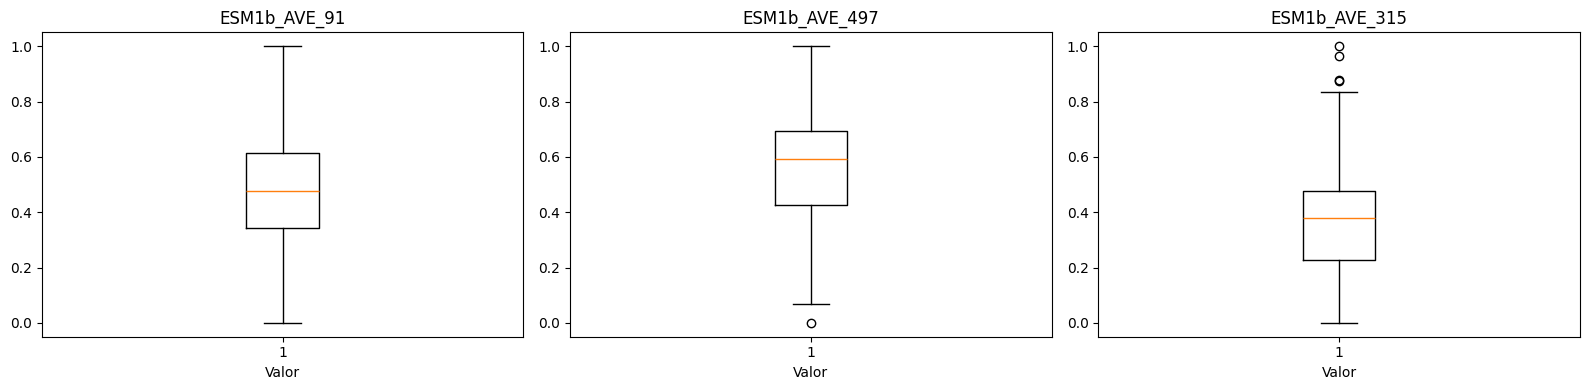

       ESM1b_AVE_91  ESM1b_AVE_497  ESM1b_AVE_315
count       1556.00        1556.00        1556.00
mean           0.48           0.56           0.36
std            0.18           0.18           0.16
min            0.00           0.00           0.00
25%            0.34           0.42           0.23
50%            0.48           0.59           0.38
75%            0.61           0.69           0.48
max            1.00           1.00           1.00


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].boxplot(df["ESM1b_AVE_91"])
axes[0].set_title("ESM1b_AVE_91")
axes[0].set_xlabel("Valor")

axes[1].boxplot(df['ESM1b_AVE_497'])
axes[1].set_title("ESM1b_AVE_497")
axes[1].set_xlabel("Valor")

axes[2].boxplot(df['ESM1b_AVE_315'])
axes[2].set_title("ESM1b_AVE_315")
axes[2].set_xlabel("Valor")

plt.tight_layout()
plt.show()

print(df[["ESM1b_AVE_91", "ESM1b_AVE_497", "ESM1b_AVE_315"]].describe())

In [28]:
r_ESM1b_AVE_91 = df["ESM1b_AVE_91"].corr(df["Class"])
r_ESM1b_AVE_497 = df["ESM1b_AVE_497"].corr(df["Class"])
r_ESM1b_AVE_315 = df["ESM1b_AVE_315"].corr(df["Class"])

print("Correlación de ESM1b_AVE_91 con Class:", r_ESM1b_AVE_91)
print("Correlación de ESM1b_AVE_497 con Class:", r_ESM1b_AVE_497)
print("Correlación de ESM1b_AVE_315 con Class:", r_ESM1b_AVE_315)

Correlación de ESM1b_AVE_91 con Class: 0.4080731641280564
Correlación de ESM1b_AVE_497 con Class: 0.4161820444339947
Correlación de ESM1b_AVE_315 con Class: -0.38567370340631874


In [42]:
def show_correlation_scatter(x, y, xlabel, ylabel, title, ax):
    pendiente, intercepto = np.polyfit(x, y, 1)

    ax.scatter(x, y, alpha=0.75)
    x_tendencia = np.linspace(x.min(), x.max(), 100)
    ax.plot(
        x_tendencia,
        pendiente * x_tendencia + intercepto,
        color="tab:red",
        label="Tendencia"
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

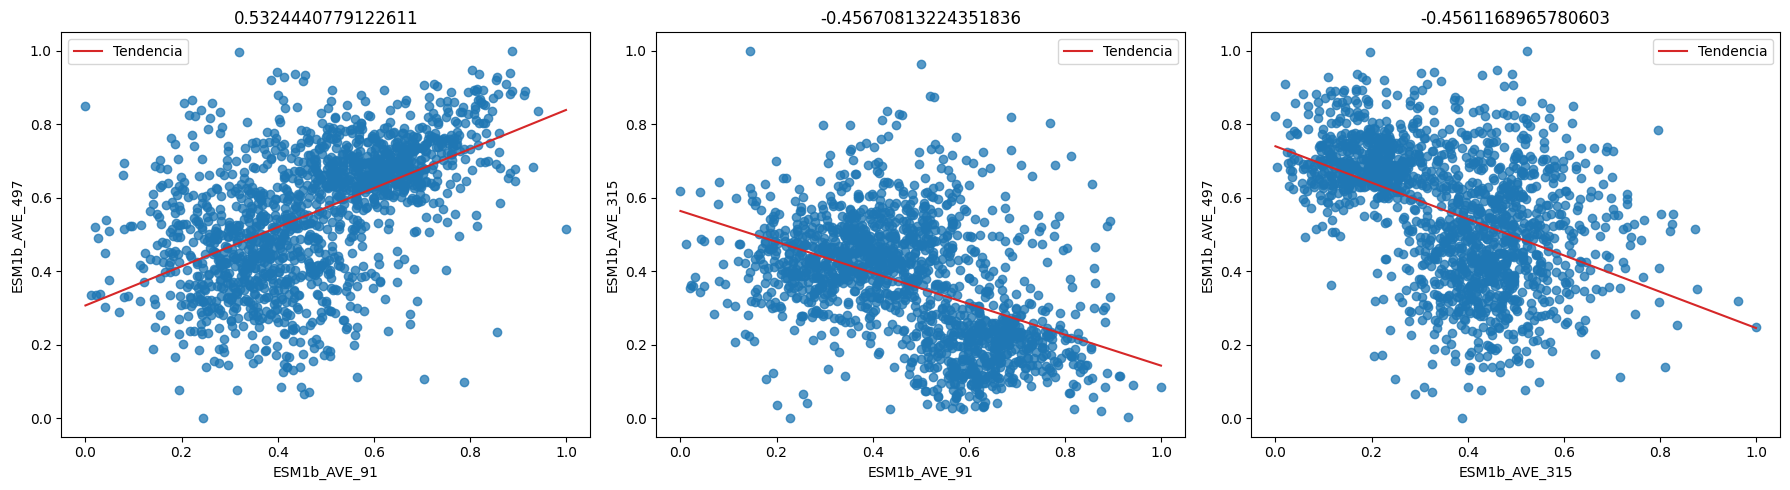

In [45]:
r_ESM1b_AVE_91_497 = df["ESM1b_AVE_91"].corr(df["ESM1b_AVE_497"])
r_ESM1b_AVE_91_315 = df["ESM1b_AVE_91"].corr(df["ESM1b_AVE_315"])
r_ESM1b_AVE_315_497 = df["ESM1b_AVE_315"].corr(df["ESM1b_AVE_497"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

show_correlation_scatter(
    df["ESM1b_AVE_91"], df["ESM1b_AVE_497"],
    "ESM1b_AVE_91", "ESM1b_AVE_497", str(r_ESM1b_AVE_91_497), axes[0]
)

show_correlation_scatter(
    df["ESM1b_AVE_91"], df["ESM1b_AVE_315"],
    "ESM1b_AVE_91", "ESM1b_AVE_315", str(r_ESM1b_AVE_91_315), axes[1]
)

show_correlation_scatter(
    df["ESM1b_AVE_315"], df["ESM1b_AVE_497"],
    "ESM1b_AVE_315", "ESM1b_AVE_497", str(r_ESM1b_AVE_315_497), axes[2]
)

plt.tight_layout()
plt.show()
